# 1. Importar as bibliotecas

In [ ]:
# Importar as bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
#from google.colab import files

# 2. Carregar a imagem

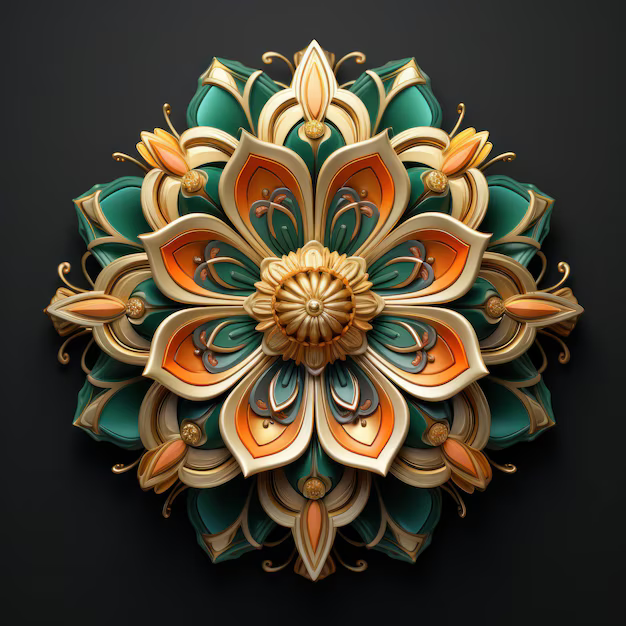

In [ ]:
arquivos = files.upload()

# nome_arquivo = r'C:\Users\Lily\Documents\GitHub\atividades-processamento-de-imagens\atividade\atividade-2\input\mandala.png
nome_arquivo = next(iter(arquivos))
imagem = Image.open(nome_arquivo)

imagem

# 3. Converter a imagem para níveis de cinza

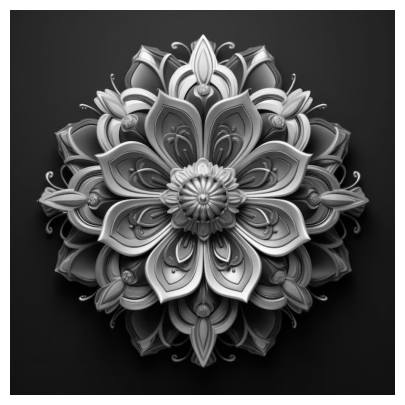

In [ ]:
imagem_cinza = imagem.convert("L")

plt.figure(figsize=(7, 5))
plt.imshow(imagem_cinza, cmap="gray")
plt.axis("off")
plt.show()

# 4. Histograma

### a) Método 1

In [ ]:
# --- Cada posição da matriz contém uma intensidade entre: 0 (Preto) e 255 (branco) ---

matriz = np.array(imagem_cinza)

print("Dimensões da matriz:", matriz.shape)
print(matriz)

Dimensões da matriz: (626, 626)
[[36 36 36 ... 33 33 33]
 [36 36 36 ... 33 33 33]
 [36 36 36 ... 33 33 33]
 ...
 [18 18 18 ... 18 17 17]
 [18 18 18 ... 17 17 17]
 [18 18 18 ... 17 17 17]]


In [ ]:
# --- Criar o vetor e contar os pixels ---

# Uma posição para cada intensidade: 0 até 255
histograma = np.zeros(256, dtype=int)

# Percorrer cada pixel da imagem
for linha in matriz:
    for pixel in linha:
        intensidade = int(pixel)
        histograma[intensidade] += 1

print(histograma)

[ 485 1969 3522 3042 3749 3575 3376 3520 3352 3376 3721 3662 4478 4562
 3907 5193 4134 5853 7683 7347 9465 6101 9269 5092 4414 3563 2780 2331
 2125 2462 2715 2628 2732 3372 4620 4477 5469 6352 6097 6449 6348 5321
 5247 5249 5143 4752 5123 4561 4292 4199 3833 3661 3747 4499 4220 5004
 1519 1260 1205 1361 1411 1387 1271 1454 1476 1469 1281 1308 1279 1294
 1381 1287 1235 1228 1263 1173 1206 1198 1190 1237 1187 1141 1144 1149
 1192 1160 1154 1116 1124 1154 1195 1138 1102 1122 1127 1021 1088 1112
 1115 1078 1110 1160 1092 1040 1044 1156 1134 1064 1029 1013  976 1018
  990  991  962  950  932  898  910  929  891  845  874  893  901  858
 1001  949  904  899  923  931  937  837  876  792  739  754  735  683
  741  715  719  636  719  697  654  640  613  634  629  600  633  593
  597  619  667  533  617  589  591  556  561  571  527  539  543  526
  479  527  524  546  549  504  535  519  496  489  498  495  509  501
  476  524  475  497  486  480  445  462  438  450  494  447  448  431
  425 

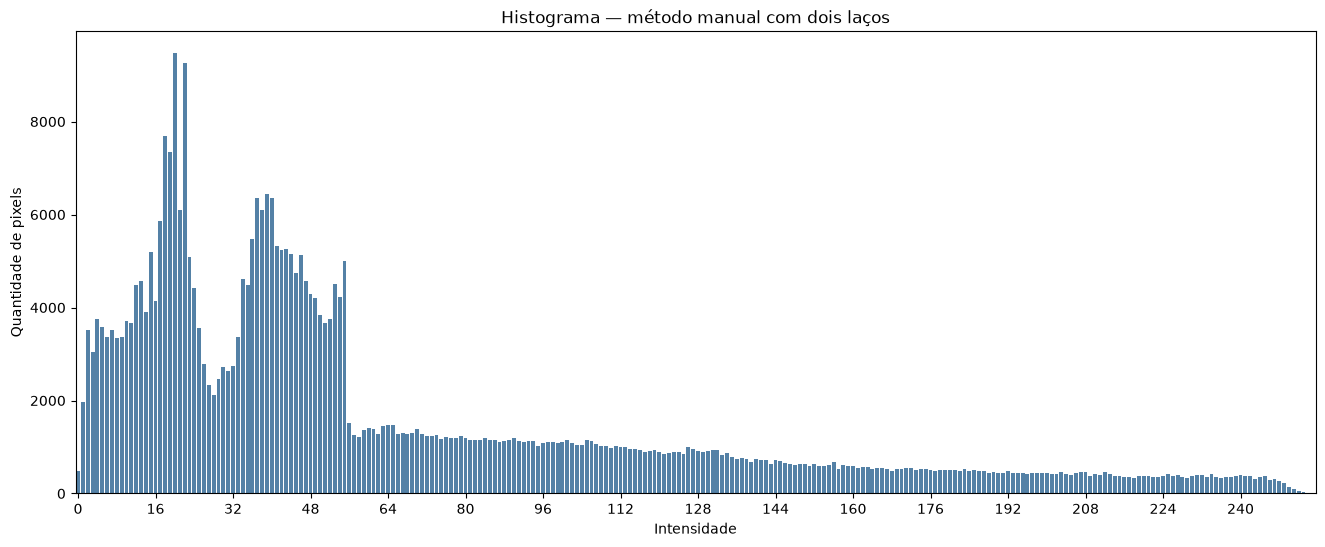

In [ ]:
intensidades = np.arange(256)

plt.figure(figsize=(16, 6))

sns.barplot(
    x=intensidades,
    y=histograma,
    color="steelblue"
)

plt.title("Histograma — método manual com dois laços")
plt.xlabel("Intensidade")
plt.ylabel("Quantidade de pixels")

plt.xticks(
    ticks=np.arange(0, 256, 16),
    labels=np.arange(0, 256, 16)
)

plt.show()

### b) Método 2

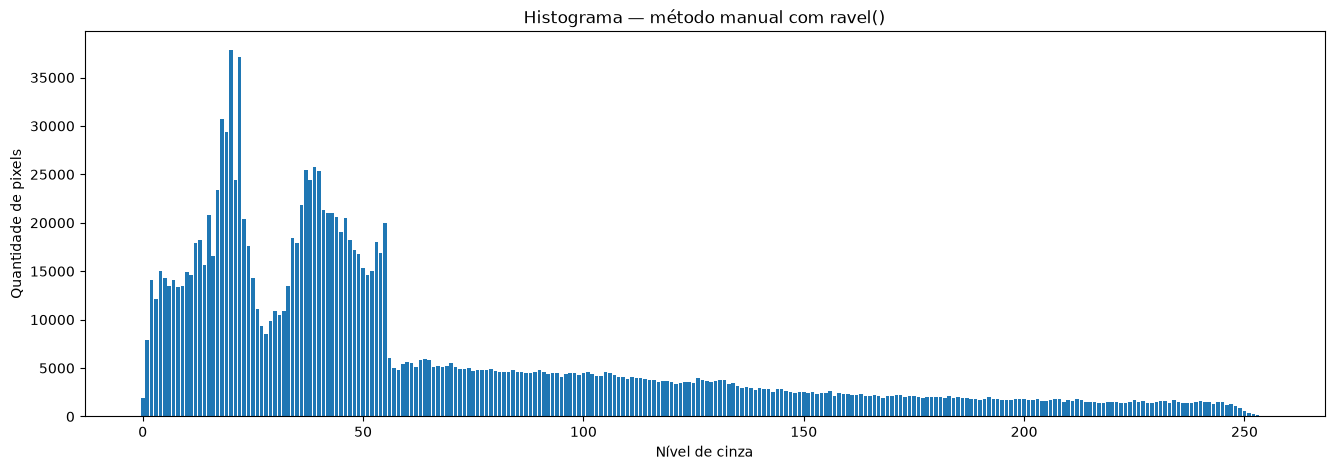

In [ ]:
# Calcula e plota o histograma percorrendo a imagem pixel a pixel.
# Espera uma imagem em tons de cinza (uint8).

matriz = np.array(imagem_cinza, dtype=np.uint8)

for px in matriz.ravel():
    histograma[px] += 1

plt.figure(figsize=(16, 5))

plt.bar(range(256), histograma)
plt.xlabel("Nível de cinza")
plt.ylabel("Quantidade de pixels")
plt.title("Histograma — método manual com ravel()")
plt.show()

### c) Método 3

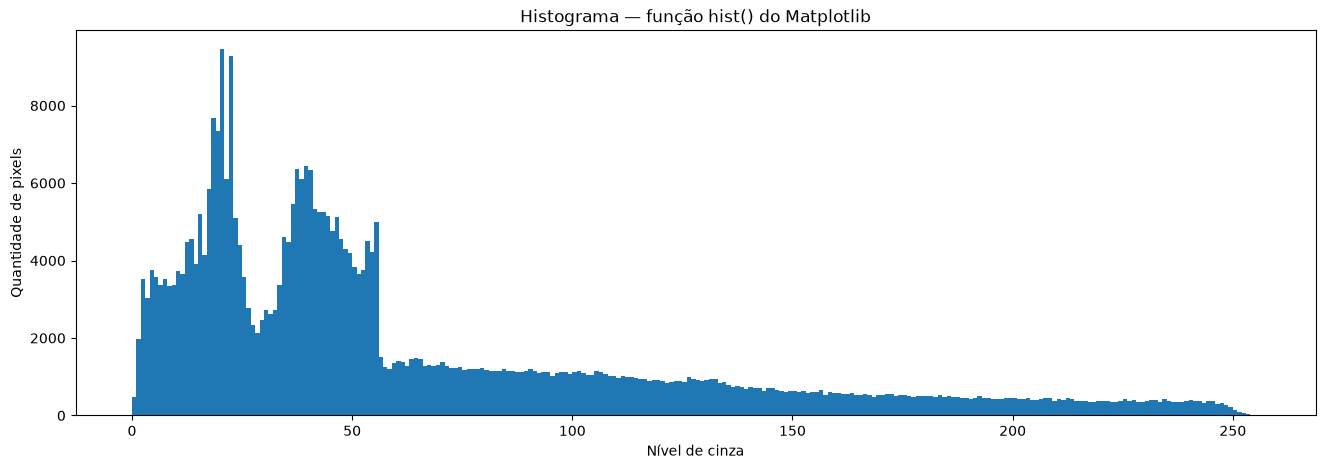

In [ ]:
# Plota o histograma usando a função pronta hist() do Matplotlib.
# Espera uma imagem em tons de cinza (uint8).

plt.figure(figsize=(16, 5))
plt.hist(np.ravel(imagem_cinza), bins=256, range=(0, 256))
plt.xlabel("Nível de cinza")
plt.ylabel("Quantidade de pixels")
plt.title("Histograma — função hist() do Matplotlib")
plt.show()

# 5. Negativo

### a) Calcula o negativo digital percorrendo a imagem pixel a pixel. Espera uma imagem em tons de cinza (uint8).

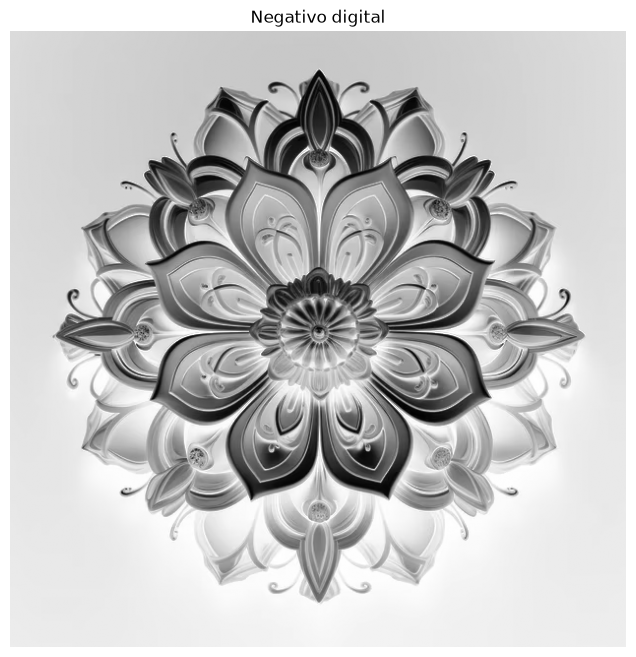

In [ ]:
# Converter a imagem PIL em tons de cinza para uma matriz NumPy
imagem = np.array(imagem_cinza, dtype=np.uint8)

# Criar uma matriz vazia com as mesmas dimensões
resultado = np.zeros_like(imagem)

# Calcular o negativo pixel a pixel
for i in range(imagem.shape[0]):
    for j in range(imagem.shape[1]):
        resultado[i, j] = 255 - imagem[i, j]

# Mostrar o resultado
plt.figure(figsize=(8, 8))
plt.imshow(resultado, cmap="gray", vmin=0, vmax=255)
plt.title("Negativo digital")
plt.axis("off")
plt.show()

### b) Calcula o negativo digital usando operação vetorizada do NumPy. Espera uma imagem em tons de cinza (uint8).

In [ ]:
def negativo_numpy(imagem):
    """
    Calcula o negativo digital usando uma operação vetorizada do NumPy.
    """
    imagem = np.array(imagem, dtype=np.uint8)
    return 255 - imagem

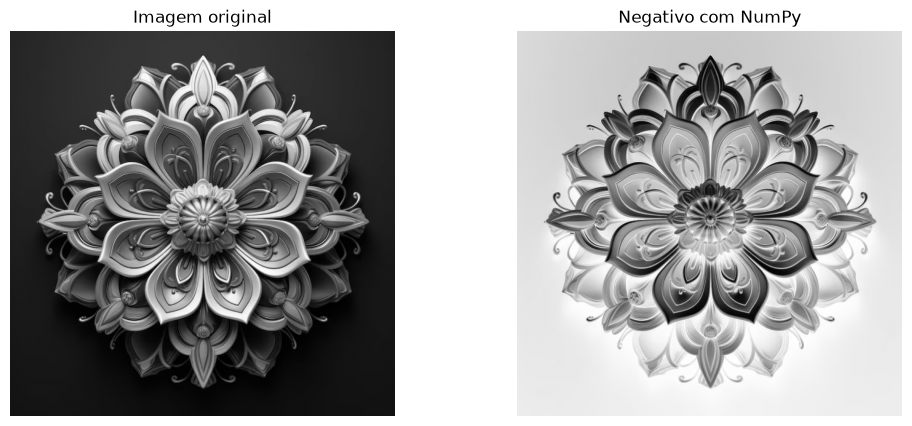

In [ ]:
imagem_negativa = negativo_numpy(imagem_cinza)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(imagem_cinza, cmap="gray", vmin=0, vmax=255)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagem_negativa, cmap="gray", vmin=0, vmax=255)
plt.title("Negativo com NumPy")
plt.axis("off")

plt.show()

# 6. Equalização do Histograma

### a) Equaliza o histograma manualmente. Espera uma imagem em tons de cinza (uint8).


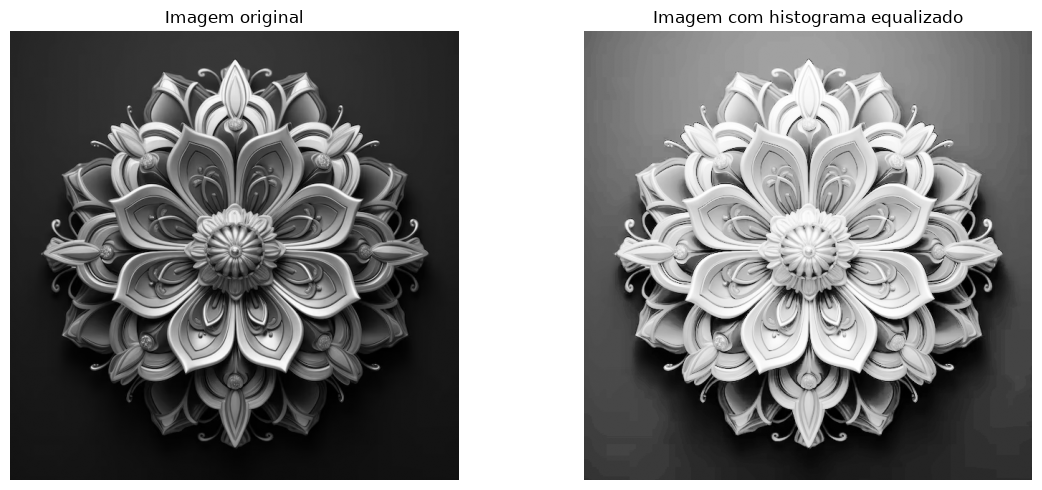

In [ ]:
matriz_cinza = np.array(imagem_cinza, dtype=np.uint8)

# Criar um vetor para armazenar as 256 intensidades
histograma = np.zeros(256, dtype=int)

# Calcular manualmente o histograma
for i in range(matriz_cinza.shape[0]):
    for j in range(matriz_cinza.shape[1]):
        nivel = matriz_cinza[i, j]
        histograma[nivel] += 1

# Calcular a distribuição acumulada (CDF)
cdf = np.cumsum(histograma)
""" cdf = np.zeros(256, dtype=int)
    cdf[0] = histograma[0]

    for nivel in range(1, 256):
        cdf[nivel] = cdf[nivel - 1] + histograma[nivel]"""

# Desconsiderar intensidades ausentes
cdf_min = cdf[cdf > 0].min()

# Normalizar a CDF para o intervalo intervalo de 0 a 255
cdf_normalizada = (
    255 * (cdf - cdf_min) / (cdf[-1] - cdf_min)
)

cdf_normalizada = np.clip(cdf_normalizada, 0, 255)

# Criar a matriz que receberá o resultado
resultado = np.zeros_like(matriz_cinza)

# Substituir cada pixel pela nova intensidade
for i in range(matriz_cinza.shape[0]):
    for j in range(matriz_cinza.shape[1]):
        nivel_original = matriz_cinza[i, j]
        resultado[i, j] = cdf_normalizada[nivel_original]

# Converter o resultado para uint8
resultado = resultado.astype(np.uint8)

# Mostrar a imagem original e a imagem equalizada
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(matriz_cinza, cmap="gray", vmin=0, vmax=255)
plt.title("Imagem original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resultado, cmap="gray", vmin=0, vmax=255)
plt.title("Imagem com histograma equalizado")
plt.axis("off")

plt.tight_layout()
plt.show()

### b) Equaliza o histograma usando a função pronta do OpenCV.

In [ ]:
%pip install opencv-python-headless

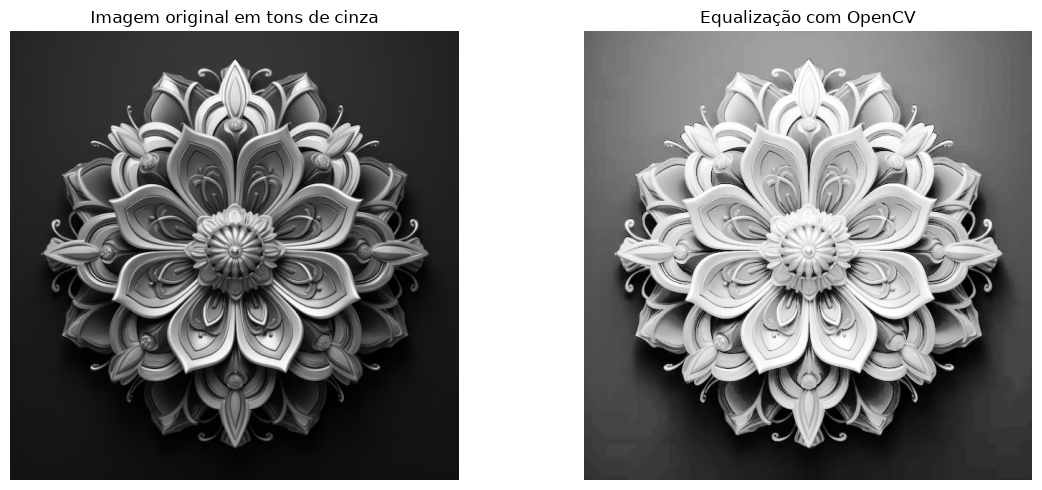

In [ ]:
import cv2

def equalizacao_histograma_opencv(imagem):
    # Converter a imagem do Pillow para uma matriz NumPy uint8
    imagem = np.array(imagem, dtype=np.uint8)

    # Equalizar o histograma com a função pronta do OpenCV
    return cv2.equalizeHist(imagem)

# Aplicar a equalização
imagem_equalizada = equalizacao_histograma_opencv(imagem_cinza)

# Mostrar os resultados
plt.figure(figsize=(12, 5))

# Imagem original em tons de cinza
plt.subplot(1, 2, 1)
plt.imshow(imagem_cinza, cmap="gray", vmin=0, vmax=255)
plt.title("Imagem original em tons de cinza")
plt.axis("off")

# Imagem com histograma equalizado
plt.subplot(1, 2, 2)
plt.imshow(imagem_equalizada, cmap="gray", vmin=0, vmax=255)
plt.title("Equalização com OpenCV")
plt.axis("off")

plt.tight_layout()
plt.show()

# 7. Correção Gamma

### a) Correção de gama pixel a pixel

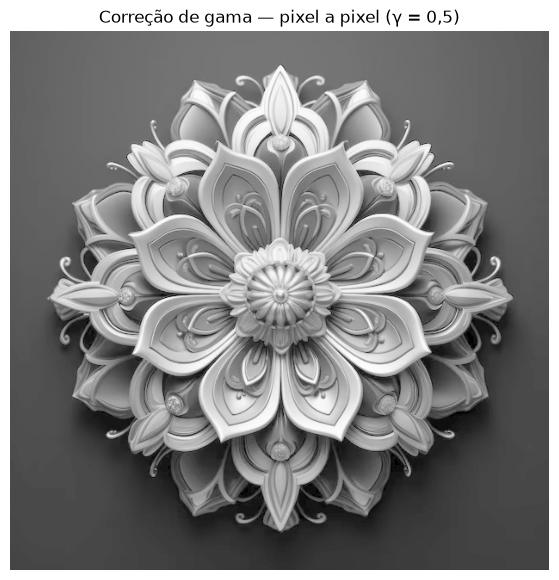

In [ ]:
def correcao_gamma_pixel_a_pixel(imagem, gamma):
    """
    Aplica a correção de gama percorrendo a imagem pixel a pixel.

    gamma < 1: clareia a imagem
    gamma > 1: escurece a imagem
    gamma = 1: mantém a imagem original
    """

    # Verificar se o valor de gama é válido
    if gamma <= 0:
        raise ValueError("O valor de gamma deve ser maior que zero.")

    # Converter a imagem do Pillow para uma matriz NumPy
    imagem = np.array(imagem, dtype=np.uint8)

    # Criar uma matriz vazia com as mesmas dimensões da imagem
    resultado = np.zeros_like(imagem)

    # Percorrer cada pixel da imagem
    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):

            # Normalizar a intensidade para o intervalo de 0 a 1
            intensidade_normalizada = imagem[i, j] / 255.0

            # Aplicar a fórmula da correção de gama
            nova_intensidade = 255 * (intensidade_normalizada ** gamma)

            # Armazenar o novo valor na imagem de resultado
            resultado[i, j] = nova_intensidade

    # Retornar o resultado no formato uint8
    return resultado.astype(np.uint8)


# Aplicar a correção pixel a pixel
imagem_gamma_pixel = correcao_gamma_pixel_a_pixel(
    imagem_cinza,
    gamma=0.5
)

# Mostrar a imagem
plt.figure(figsize=(7, 7))
plt.imshow(imagem_gamma_pixel, cmap="gray", vmin=0, vmax=255)
plt.title("Correção de gama — pixel a pixel (γ = 0,5)")
plt.axis("off")
plt.show()

### b) Correção de gama com NumPy

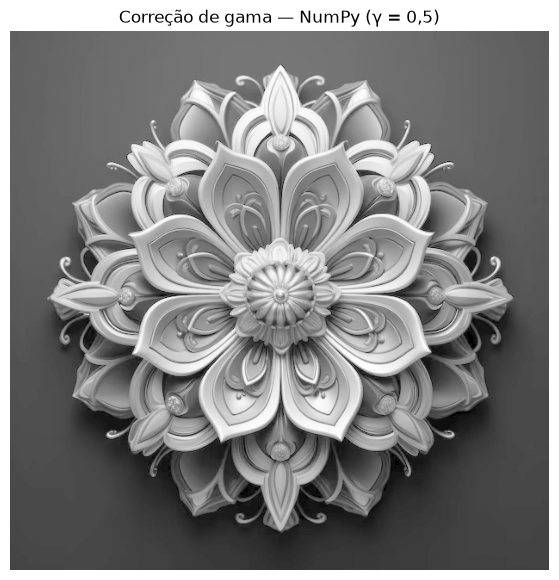

In [ ]:
def correcao_gamma_numpy(imagem, gamma):
    """
    Aplica a correção de gama usando operações vetorizadas do NumPy.

    gamma < 1: clareia a imagem
    gamma > 1: escurece a imagem
    gamma = 1: mantém a imagem original
    """

    # Verificar se o valor de gama é válido
    if gamma <= 0:
        raise ValueError("O valor de gamma deve ser maior que zero.")

    # Converter a imagem do Pillow para uma matriz NumPy
    imagem = np.array(imagem, dtype=np.uint8)

    # Normalizar todas as intensidades para o intervalo de 0 a 1
    imagem_normalizada = imagem / 255.0

    # Aplicar a correção de gama em todos os pixels simultaneamente
    resultado = 255 * (imagem_normalizada ** gamma)

    # Retornar o resultado no formato uint8
    return resultado.astype(np.uint8)


# Aplicar a correção vetorizada
imagem_gamma_numpy = correcao_gamma_numpy(
    imagem_cinza,
    gamma=0.5
)

# Mostrar a imagem
plt.figure(figsize=(7, 7))
plt.imshow(imagem_gamma_numpy, cmap="gray", vmin=0, vmax=255)
plt.title("Correção de gama — NumPy (γ = 0,5)")
plt.axis("off")
plt.show()